<a href="https://colab.research.google.com/github/yosrasallemi/triagegeist/blob/main/notebooks/03_Modeling_Baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 0.1 — Setup

In [9]:
# ============================================================
# CELL 0.1 — Install & Import Libraries
# ============================================================

!pip install lightgbm catboost xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import (
    cohen_kappa_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import xgboost  as xgb
import lightgbm as lgb
import catboost as cb

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

SEED     = 2025
N_FOLDS  = 5
np.random.seed(SEED)

print("✅ Libraries imported successfully")
print(f"  LightGBM : {lgb.__version__}")
print(f"  XGBoost  : {xgb.__version__}")
print(f"  CatBoost : {cb.__version__}")

✅ Libraries imported successfully
  LightGBM : 4.6.0
  XGBoost  : 3.2.0
  CatBoost : 1.2.10


### 0.2 — Mount Drive

In [10]:
# ============================================================
# CELL 0.2 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


### PART A — LOAD ENGINEERED DATASET

In [11]:
# ============================================================
# PART A — LOAD ENGINEERED DATASET
# ============================================================

import os

OUTPUT_PATH = '/content/drive/MyDrive/triagegeist/output/'

train_full = pd.read_parquet(
    OUTPUT_PATH + 'train_features.parquet')
test_full  = pd.read_parquet(
    OUTPUT_PATH + 'test_features.parquet')

print("=" * 60)
print("ENGINEERED DATASET LOADED")
print("=" * 60)
print(f"  train_full : {train_full.shape[0]:,} x "
      f"{train_full.shape[1]}")
print(f"  test_full  : {test_full.shape[0]:,} x "
      f"{test_full.shape[1]}")
print()
print(f"  Target distribution :")
dist = train_full['triage_acuity'].value_counts(
    normalize=True).sort_index() * 100
for esi, pct in dist.items():
    print(f"    ESI-{esi} : {pct:.1f}%")

ENGINEERED DATASET LOADED
  train_full : 80,000 x 398
  test_full  : 20,000 x 397

  Target distribution :
    ESI-1 : 4.0%
    ESI-2 : 16.8%
    ESI-3 : 36.2%
    ESI-4 : 28.8%
    ESI-5 : 14.2%


### B — Create X_structured

In [12]:
# ============================================================
# PART B — CREATE X_STRUCTURED (Structured Data Only)
# ============================================================

# Définir toutes les features texte à exclure
tfidf_cols   = [c for c in train_full.columns
                if c.startswith('cc_')]
keyword_cols = [c for c in train_full.columns
                if c.startswith('has_')]
text_length  = [
    'complaint_n_words',
    'complaint_n_chars',
    'critical_keyword_count'
]

all_text_cols = tfidf_cols + keyword_cols + text_length

print("=" * 60)
print("B — STRUCTURED DATA ONLY")
print("=" * 60)
print()
print(f"  Features excluded :")
print(f"    TF-IDF features   : {len(tfidf_cols)}")
print(f"    Keyword features  : {len(keyword_cols)}")
print(f"    Text length feats : {len(text_length)}")
print(f"    Total excluded    : {len(all_text_cols)}")
print()

# Créer X_structured
X_structured = train_full.drop(
    columns=all_text_cols + ['triage_acuity'],
    errors='ignore'
)
y = train_full['triage_acuity'].values - 1  # 0-indexed

X_test_structured = test_full.drop(
    columns=all_text_cols,
    errors='ignore'
)

# Vérification obligatoire
assert not any(
    c.startswith('cc_')
    for c in X_structured.columns), \
    "❌ TF-IDF features still present!"
assert not any(
    c.startswith('has_')
    for c in X_structured.columns), \
    "❌ Keyword features still present!"
assert 'complaint_n_chars' \
    not in X_structured.columns, \
    "❌ Text length features still present!"
assert 'triage_acuity' \
    not in X_structured.columns, \
    "❌ Target still present!"

print(f"  ✅ Structured features : {X_structured.shape[1]}")
print(f"  ✅ No text features remaining")
print(f"  ✅ No target leakage")
print()
print(f"  X_structured shape : {X_structured.shape}")
print(f"  y classes          : {np.unique(y)}")
print()
print("  Feature groups retained :")
vital_feats = [c for c in X_structured.columns
               if c in ['systolic_bp','diastolic_bp',
                        'heart_rate','respiratory_rate',
                        'temperature_c','spo2','gcs_total',
                        'pain_score','shock_index',
                        'mean_arterial_pressure',
                        'pulse_pressure']]
flag_feats  = [c for c in X_structured.columns
               if c in ['hypoxemia_flag','tachycardia_flag',
                        'hypotension_flag','fever_flag',
                        'altered_gcs_flag','severe_pain_flag',
                        'critical_vital_count']]
util_feats  = [c for c in X_structured.columns
               if 'prior' in c or 'ed_visit' in c
               or 'admission' in c or 'medication' in c
               or 'utilization' in c]
hx_feats    = [c for c in X_structured.columns
               if c.startswith('hx_')]

print(f"    Vital Signs       : {len(vital_feats)}")
print(f"    Clinical Flags    : {len(flag_feats)}")
print(f"    Utilization       : {len(util_feats)}")
print(f"    Comorbidities     : {len(hx_feats)}")
print(f"    Other             : "
      f"{X_structured.shape[1] - len(vital_feats) - len(flag_feats) - len(util_feats) - len(hx_feats)}")

B — STRUCTURED DATA ONLY

  Features excluded :
    TF-IDF features   : 300
    Keyword features  : 11
    Text length feats : 3
    Total excluded    : 314

  ✅ Structured features : 83
  ✅ No text features remaining
  ✅ No target leakage

  X_structured shape : (80000, 83)
  y classes          : [0 1 2 3 4]

  Feature groups retained :
    Vital Signs       : 11
    Clinical Flags    : 7
    Utilization       : 6
    Comorbidities     : 25
    Other             : 34


### C — Train/Validation Strategy

In [13]:
# ============================================================
# PART C — TRAIN / VALIDATION STRATEGY
# ============================================================

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

print("=" * 55)
print("C — TRAIN / VALIDATION STRATEGY")
print("=" * 55)
print(f"""
  Method       : Stratified {N_FOLDS}-Fold CV
  Shuffle      : True
  Random State : {SEED}
  Train size   : ~{int(len(X_structured)*0.8):,} per fold
  Val size     : ~{int(len(X_structured)*0.2):,} per fold

  Why Stratified ?
  → ESI-1 = only 4% of patients
  → Each fold must preserve class distribution
""")

# Vérifier distribution
print("  Class distribution per fold :")
for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X_structured, y), 1):
    dist_fold = pd.Series(
        y[val_idx]).value_counts(
        normalize=True).sort_index() * 100
    print(f"  Fold {fold} : " +
          "  ".join([
              f"ESI-{i+1}={v:.1f}%"
              for i, v in enumerate(dist_fold.values)
          ]))

C — TRAIN / VALIDATION STRATEGY

  Method       : Stratified 5-Fold CV
  Shuffle      : True
  Random State : 2025
  Train size   : ~64,000 per fold
  Val size     : ~16,000 per fold

  Why Stratified ?
  → ESI-1 = only 4% of patients
  → Each fold must preserve class distribution

  Class distribution per fold :
  Fold 1 : ESI-1=4.0%  ESI-2=16.8%  ESI-3=36.1%  ESI-4=28.8%  ESI-5=14.2%
  Fold 2 : ESI-1=4.0%  ESI-2=16.8%  ESI-3=36.1%  ESI-4=28.8%  ESI-5=14.2%
  Fold 3 : ESI-1=4.0%  ESI-2=16.8%  ESI-3=36.2%  ESI-4=28.8%  ESI-5=14.2%
  Fold 4 : ESI-1=4.0%  ESI-2=16.8%  ESI-3=36.1%  ESI-4=28.8%  ESI-5=14.2%
  Fold 5 : ESI-1=4.0%  ESI-2=16.8%  ESI-3=36.1%  ESI-4=28.8%  ESI-5=14.2%


### D — Evaluation Framework

In [30]:
# ============================================================
# PART D — EVALUATION FRAMEWORK
# ============================================================

def evaluate_predictions(y_true, y_pred,
                          model_name='Model'):
    qwk  = cohen_kappa_score(
        y_true, y_pred, weights='quadratic')
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(
        y_true, y_pred,
        average='weighted', zero_division=0)
    rec  = recall_score(
        y_true, y_pred,
        average='weighted', zero_division=0)
    f1   = f1_score(
        y_true, y_pred,
        average='weighted', zero_division=0)

    esi1_mask  = (y_true == 0)
    esi1_pred  = (y_pred == 0)
    esi1_tp    = (esi1_mask & esi1_pred).sum()
    esi1_fp    = (~esi1_mask & esi1_pred).sum()
    esi1_fn    = (esi1_mask & ~esi1_pred).sum()

    esi1_prec  = esi1_tp / (esi1_tp + esi1_fp) \
                 if (esi1_tp + esi1_fp) > 0 else 0
    esi1_rec   = esi1_tp / (esi1_tp + esi1_fn) \
                 if (esi1_tp + esi1_fn) > 0 else 0

    return {
        'Model'         : model_name,
        'QWK'           : round(qwk,       4),
        'Accuracy'      : round(acc,       4),
        'F1_Weighted'   : round(f1,        4),
        'Precision'     : round(prec,      4),
        'Recall'        : round(rec,       4),
        'ESI1_Precision': round(esi1_prec, 4),
        'ESI1_Recall'   : round(esi1_rec,  4)
    }

def run_cross_validation(model, X, y,
                          model_name,
                          predict_proba=True):
    skf_ = StratifiedKFold(
        n_splits=N_FOLDS,
        shuffle=True,
        random_state=SEED
    )
    oof_preds = np.zeros(len(X), dtype=int)
    qwk_folds = []

    print(f"\n  Training {model_name}...")
    print(f"  {'Fold':<8} {'QWK':>8}")
    print(f"  {'-'*20}")

    for fold, (tr_idx, val_idx) in enumerate(
            skf_.split(X, y), 1):

        X_tr  = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr  = y[tr_idx]
        y_val = y[val_idx]

        model.fit(X_tr, y_tr)

        # ✅ CORRECTION : flatten pour CatBoost
        y_pred = np.array(
            model.predict(X_val)).flatten()

        oof_preds[val_idx] = y_pred
        qwk_fold = cohen_kappa_score(
            y_val, y_pred, weights='quadratic')
        qwk_folds.append(qwk_fold)

        print(f"  Fold {fold}/{N_FOLDS}   "
              f"{qwk_fold:.4f}")

    oof_qwk = cohen_kappa_score(
        y, oof_preds, weights='quadratic')
    metrics  = evaluate_predictions(
        y, oof_preds, model_name)
    metrics['OOF_QWK'] = round(oof_qwk, 4)
    metrics['CV_Std']  = round(
        np.std(qwk_folds), 4)

    print(f"  {'─'*20}")
    print(f"  OOF QWK : {oof_qwk:.4f} "
          f"(±{np.std(qwk_folds):.4f})")

    return metrics, oof_preds

### D- Diagnostic: Comorbidities Check

In [15]:
# ============================================================
# PART D - Diagnostic: Comorbidities Check
# ============================================================

print("=" * 60)
print("DIAGNOSTIC — HX_* COLUMNS CHECK")
print("=" * 60)
print()

# Check 1 — Dans train_full
hx_in_train_full = [c for c in train_full.columns
                    if c.startswith('hx_')]
print(f"  hx_* in train_full        : {len(hx_in_train_full)}")

# Check 2 — Dans X_structured
hx_in_structured = [c for c in X_structured.columns
                    if c.startswith('hx_')]
print(f"  hx_* in X_structured      : {len(hx_in_structured)}")

# Check 3 — Dans test_full
hx_in_test = [c for c in test_full.columns
              if c.startswith('hx_')]
print(f"  hx_* in test_full         : {len(hx_in_test)}")

print()

# Afficher les colonnes trouvées
if len(hx_in_train_full) > 0:
    print(f"  ✅ Found in train_full :")
    for col in hx_in_train_full:
        print(f"    → {col}")
else:
    print("  ❌ NO hx_* columns in train_full")
    print("     → Comorbidities were NOT exported")
    print("     → Must go back to Feature Engineering")

print()

# Check 4 — Pourquoi le compteur affiche 0
print("=" * 60)
print("DIAGNOSTIC — Why counter shows 0")
print("=" * 60)
print()
print("  Current detection code :")
print("  hx_feats = [c for c in X_structured.columns")
print("              if c.startswith('hx_')]")
print()

# Chercher des colonnes similaires
similar = [c for c in X_structured.columns
           if 'comorbid' in c.lower()
           or 'hx' in c.lower()
           or 'history' in c.lower()
           or 'hypertension' in c.lower()
           or 'diabetes' in c.lower()]

if similar:
    print(f"  Similar columns found :")
    for col in similar:
        print(f"    → {col}")
else:
    print("  ❌ No similar columns found")
    print("  → Comorbidities missing from parquet")

DIAGNOSTIC — HX_* COLUMNS CHECK

  hx_* in train_full        : 25
  hx_* in X_structured      : 25
  hx_* in test_full         : 25

  ✅ Found in train_full :
    → hx_hypertension
    → hx_diabetes_type2
    → hx_diabetes_type1
    → hx_asthma
    → hx_copd
    → hx_heart_failure
    → hx_atrial_fibrillation
    → hx_ckd
    → hx_liver_disease
    → hx_malignancy
    → hx_obesity
    → hx_depression
    → hx_anxiety
    → hx_dementia
    → hx_epilepsy
    → hx_hypothyroidism
    → hx_hyperthyroidism
    → hx_hiv
    → hx_coagulopathy
    → hx_immunosuppressed
    → hx_pregnant
    → hx_substance_use_disorder
    → hx_coronary_artery_disease
    → hx_stroke_prior
    → hx_peripheral_vascular_disease

DIAGNOSTIC — Why counter shows 0

  Current detection code :
  hx_feats = [c for c in X_structured.columns
              if c.startswith('hx_')]

  Similar columns found :
    → num_comorbidities
    → hx_hypertension
    → hx_diabetes_type2
    → hx_diabetes_type1
    → hx_asthma
    → hx

### Final data quality check before modeling

In [17]:
print("TF-IDF :", sum(c.startswith('cc_')
                      for c in X_structured.columns))

print("Keywords :", sum(c.startswith('has_')
                        for c in X_structured.columns))

for col in ['complaint_n_words',
            'complaint_n_chars',
            'critical_keyword_count']:
    print(col, col in X_structured.columns)

TF-IDF : 0
Keywords : 0
complaint_n_words False
complaint_n_chars False
critical_keyword_count False


In [18]:
print('triage_acuity' in X_structured.columns)

False


In [19]:
for col in ['patient_id',
            'triage_nurse_id']:
    print(col, col in X_structured.columns)

patient_id False
triage_nurse_id False


In [20]:
hx_cols = [c for c in X_structured.columns
           if c.startswith('hx_')]

print("Structured features :", X_structured.shape[1])
print("Comorbidities :", len(hx_cols))

Structured features : 83
Comorbidities : 25


In [21]:
print(sorted(X_structured.columns[:20]))

['age', 'age_group', 'arrival_day', 'arrival_hour', 'arrival_mode', 'arrival_month', 'arrival_season', 'chief_complaint_system', 'insurance_type', 'language', 'mental_status_triage', 'num_active_medications', 'num_comorbidities', 'num_prior_admissions_12m', 'num_prior_ed_visits_12m', 'pain_location', 'sex', 'shift', 'site_id', 'transport_origin']


 E- Model 1 : Logistic Regression

In [22]:
# ============================================================
# E — MODEL 1 : LOGISTIC REGRESSION
# ============================================================

print("=" * 55)
print("E — MODEL 1 : LOGISTIC REGRESSION")
print("=" * 55)
print("  Type    : Linear classifier")
print("  Purpose : Simple baseline")
print()

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter     = 1000,
        class_weight = 'balanced',
        random_state = SEED,
        C            = 1.0,
        solver       = 'lbfgs',
        multi_class  = 'multinomial'
    ))
])

lr_metrics, lr_oof = run_cross_validation(
    lr_pipeline, X_structured, y,
    model_name='Logistic Regression'
)

E — MODEL 1 : LOGISTIC REGRESSION
  Type    : Linear classifier
  Purpose : Simple baseline


  Training Logistic Regression...
  Fold          QWK
  --------------------
  Fold 1/5   0.9136
  Fold 2/5   0.9155
  Fold 3/5   0.9162
  Fold 4/5   0.9148
  Fold 5/5   0.9133
  ────────────────────
  OOF QWK : 0.9147 (±0.0011)


F — Model 2 : Random Forest

In [23]:
# ============================================================
# PART F — MODEL 2 : RANDOM FOREST
# ============================================================

print("=" * 55)
print("F — MODEL 2 : RANDOM FOREST")
print("=" * 55)
print("  Type    : Ensemble (bagging)")
print("  Purpose : Non-linear baseline")
print()

rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 15,
    min_samples_leaf = 10,
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1
)

rf_metrics, rf_oof = run_cross_validation(
    rf_model, X_structured, y,
    model_name='Random Forest'
)

F — MODEL 2 : RANDOM FOREST
  Type    : Ensemble (bagging)
  Purpose : Non-linear baseline


  Training Random Forest...
  Fold          QWK
  --------------------
  Fold 1/5   0.9232
  Fold 2/5   0.9263
  Fold 3/5   0.9212
  Fold 4/5   0.9212
  Fold 5/5   0.9228
  ────────────────────
  OOF QWK : 0.9229 (±0.0019)


G — Model 3 : XGBoost

In [24]:
# ============================================================
# PART G — MODEL 3 : XGBOOST
# ============================================================

print("=" * 55)
print("G — MODEL 3 : XGBOOST")
print("=" * 55)
print("  Type    : Gradient Boosting")
print("  Purpose : Strong baseline")
print()

xgb_model = xgb.XGBClassifier(
    objective        = 'multi:softmax',
    num_class        = 5,
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    eval_metric      = 'mlogloss',
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0
)

xgb_metrics, xgb_oof = run_cross_validation(
    xgb_model, X_structured, y,
    model_name='XGBoost'
)

G — MODEL 3 : XGBOOST
  Type    : Gradient Boosting
  Purpose : Strong baseline


  Training XGBoost...
  Fold          QWK
  --------------------
  Fold 1/5   0.9318
  Fold 2/5   0.9327
  Fold 3/5   0.9323
  Fold 4/5   0.9330
  Fold 5/5   0.9312
  ────────────────────
  OOF QWK : 0.9322 (±0.0006)


H — Model 4 : LightGBM

In [25]:
# ============================================================
# PART H — MODEL 4 : LIGHTGBM
# ============================================================

print("=" * 55)
print("H — MODEL 4 : LIGHTGBM")
print("=" * 55)
print("  Type    : Gradient Boosting (fast)")
print("  Purpose : Main model candidate")
print()

lgb_model = lgb.LGBMClassifier(
    objective        = 'multiclass',
    num_class        = 5,
    n_estimators     = 800,
    learning_rate    = 0.05,
    num_leaves       = 63,
    max_depth        = -1,
    min_child_samples= 30,
    subsample        = 0.85,
    colsample_bytree = 0.85,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    class_weight     = 'balanced',
    random_state     = SEED,
    verbose          = -1,
    n_jobs           = -1
)

lgb_metrics, lgb_oof = run_cross_validation(
    lgb_model, X_structured, y,
    model_name='LightGBM'
)

H — MODEL 4 : LIGHTGBM
  Type    : Gradient Boosting (fast)
  Purpose : Main model candidate


  Training LightGBM...
  Fold          QWK
  --------------------
  Fold 1/5   0.9295
  Fold 2/5   0.9330
  Fold 3/5   0.9305
  Fold 4/5   0.9302
  Fold 5/5   0.9294
  ────────────────────
  OOF QWK : 0.9305 (±0.0013)


 I — Model 5 : CatBoost

In [31]:
# ============================================================
# PART I — MODEL 5 : CATBOOST
# ============================================================

print("=" * 55)
print("I — MODEL 5 : CATBOOST")
print("=" * 55)
print("  Type    : Gradient Boosting")
print("  Purpose : Compare with LightGBM")
print()

cb_model = cb.CatBoostClassifier(
    iterations    = 500,
    learning_rate = 0.05,
    depth         = 6,
    loss_function = 'MultiClass',
    random_seed   = SEED,
    verbose       = 0,
    classes_count = 5
)

cb_metrics, cb_oof = run_cross_validation(
    cb_model, X_structured, y,
    model_name='CatBoost'
)

I — MODEL 5 : CATBOOST
  Type    : Gradient Boosting
  Purpose : Compare with LightGBM


  Training CatBoost...
  Fold          QWK
  --------------------
  Fold 1/5   0.9316
  Fold 2/5   0.9328
  Fold 3/5   0.9311
  Fold 4/5   0.9322
  Fold 5/5   0.9317
  ────────────────────
  OOF QWK : 0.9319 (±0.0006)


 J — Comparison Table

J — MODEL COMPARISON — STRUCTURED DATA ONLY

              Model    QWK  OOF_QWK  CV_Std  Accuracy  F1_Weighted  ESI1_Precision  ESI1_Recall
            XGBoost 0.9322   0.9322  0.0006    0.8590       0.8592          0.9658       0.9277
           CatBoost 0.9319   0.9319  0.0006    0.8586       0.8587          0.9770       0.9106
           LightGBM 0.9305   0.9305  0.0013    0.8545       0.8548          0.9540       0.9389
      Random Forest 0.9229   0.9229  0.0019    0.8368       0.8368          0.9054       0.9569
Logistic Regression 0.9147   0.9147  0.0011    0.8157       0.8159          0.8630       0.9621


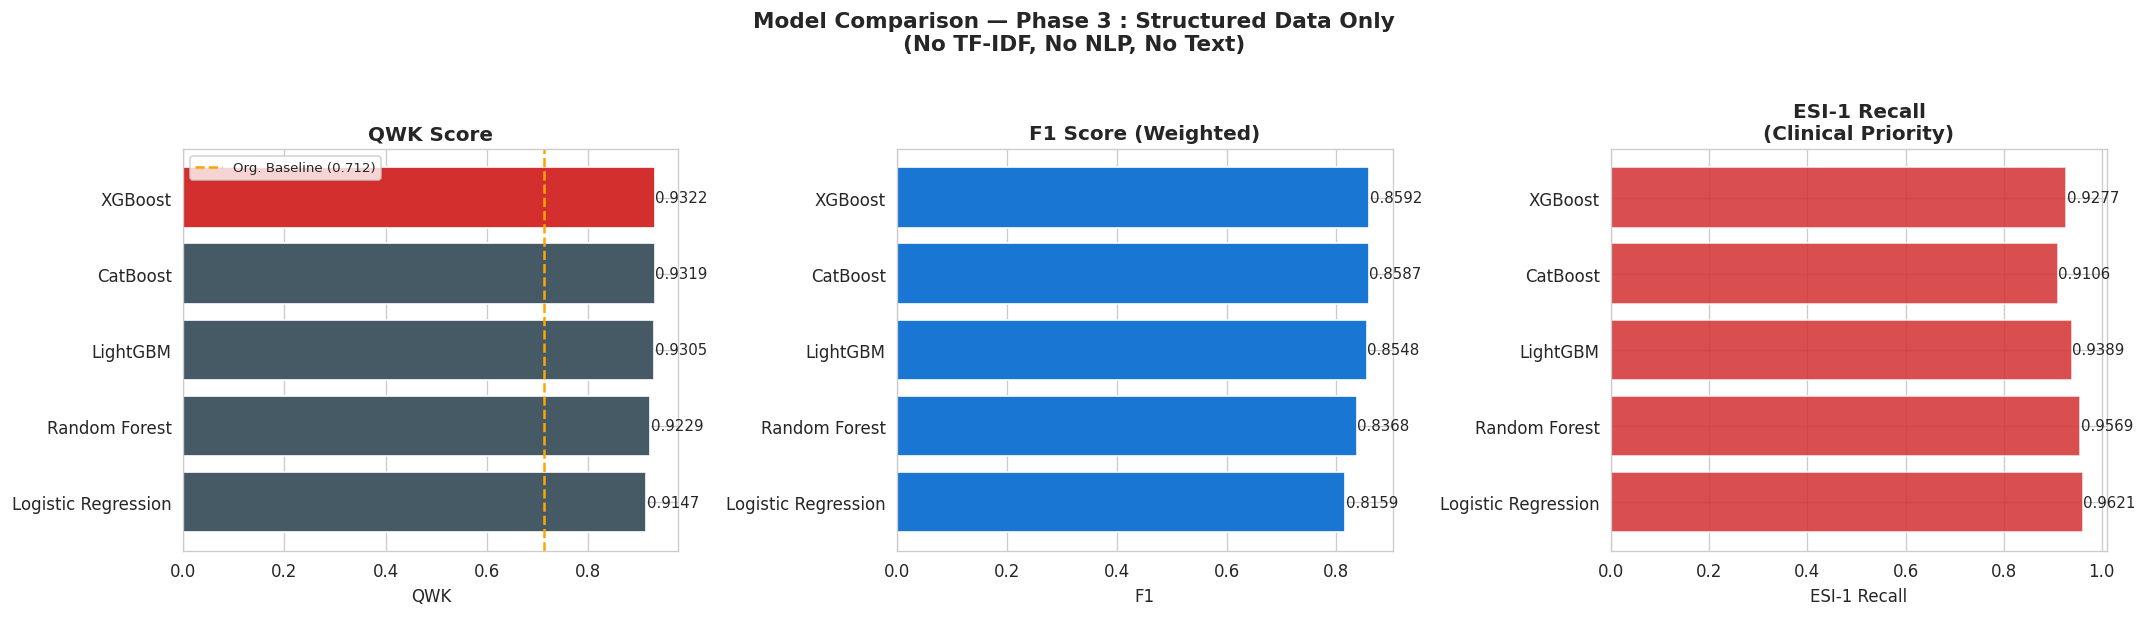

In [32]:
# ============================================================
# PART J — COMPARISON TABLE
# ============================================================

results = pd.DataFrame([
    lr_metrics,
    rf_metrics,
    xgb_metrics,
    lgb_metrics,
    cb_metrics
]).sort_values('QWK', ascending=False)

print("=" * 80)
print("J — MODEL COMPARISON — STRUCTURED DATA ONLY")
print("=" * 80)
print()
print(results[[
    'Model', 'QWK', 'OOF_QWK', 'CV_Std',
    'Accuracy', 'F1_Weighted',
    'ESI1_Precision', 'ESI1_Recall'
]].to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_colors = [
    '#d32f2f' if i == 0 else '#455a64'
    for i in range(len(results))
]

# --- QWK ---
axes[0].barh(
    results['Model'].values[::-1],
    results['QWK'].values[::-1],
    color=model_colors[::-1],
    edgecolor='white'
)
axes[0].axvline(
    0.712, color='orange',
    linestyle='--', linewidth=1.5,
    label='Org. Baseline (0.712)'
)
axes[0].set_title('QWK Score',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('QWK')
axes[0].legend(fontsize=8)
for i, (_, row) in enumerate(
        results[::-1].iterrows()):
    axes[0].text(
        row['QWK'] + 0.001, i,
        f"{row['QWK']:.4f}",
        va='center', fontsize=9
    )

# --- F1 ---
axes[1].barh(
    results['Model'].values[::-1],
    results['F1_Weighted'].values[::-1],
    color='#1976d2', edgecolor='white'
)
axes[1].set_title('F1 Score (Weighted)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('F1')
for i, (_, row) in enumerate(
        results[::-1].iterrows()):
    axes[1].text(
        row['F1_Weighted'] + 0.001, i,
        f"{row['F1_Weighted']:.4f}",
        va='center', fontsize=9
    )

# --- ESI-1 Recall ---
axes[2].barh(
    results['Model'].values[::-1],
    results['ESI1_Recall'].values[::-1],
    color='#d32f2f', edgecolor='white',
    alpha=0.85
)
axes[2].set_title('ESI-1 Recall\n(Clinical Priority)',
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('ESI-1 Recall')
for i, (_, row) in enumerate(
        results[::-1].iterrows()):
    axes[2].text(
        row['ESI1_Recall'] + 0.001, i,
        f"{row['ESI1_Recall']:.4f}",
        va='center', fontsize=9
    )

plt.suptitle(
    'Model Comparison — Phase 3 : Structured Data Only\n'
    '(No TF-IDF, No NLP, No Text)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

K — Confusion Matrix Best Model

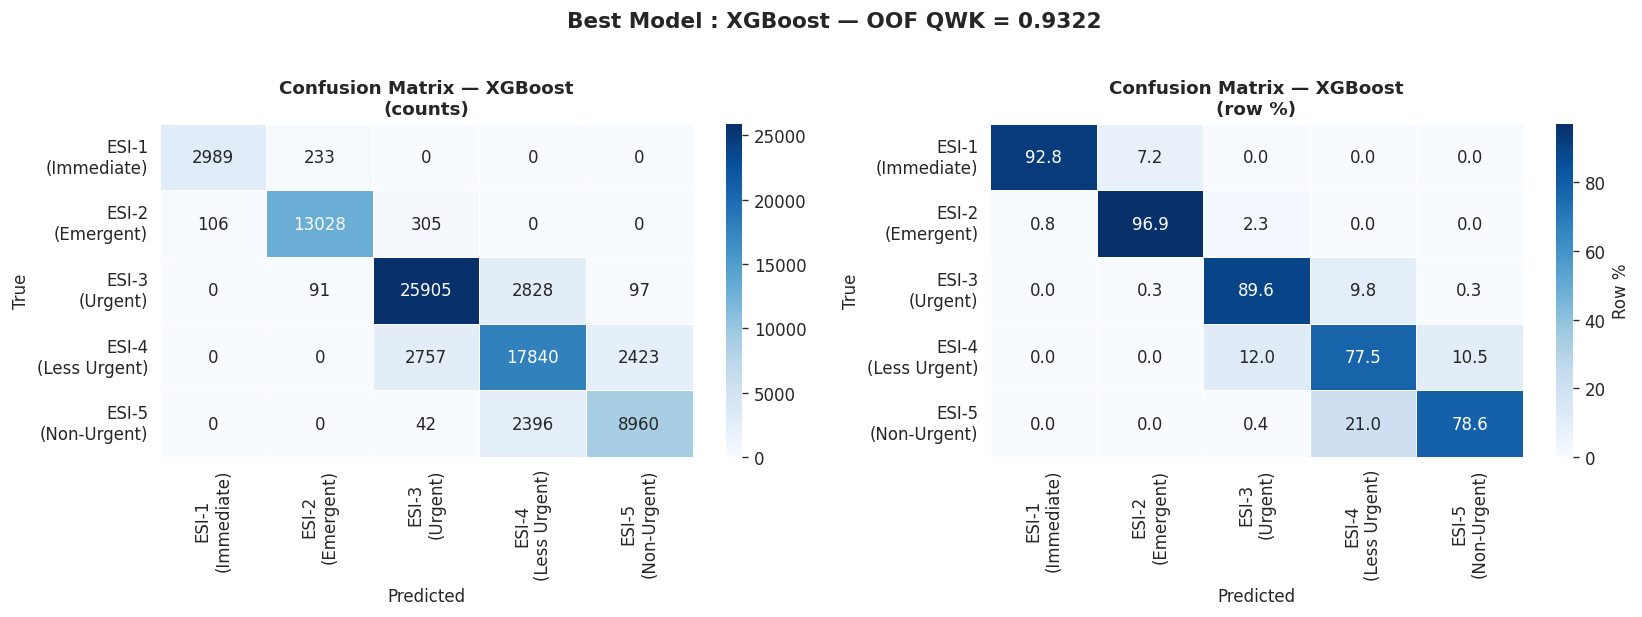


              precision    recall  f1-score   support

       ESI-1       0.97      0.93      0.95      3222
       ESI-2       0.98      0.97      0.97     13439
       ESI-3       0.89      0.90      0.89     28921
       ESI-4       0.77      0.77      0.77     23020
       ESI-5       0.78      0.79      0.78     11398

    accuracy                           0.86     80000
   macro avg       0.88      0.87      0.87     80000
weighted avg       0.86      0.86      0.86     80000



In [33]:
# ============================================================
# PART K — CONFUSION MATRIX — BEST MODEL
# ============================================================

best_name = results.iloc[0]['Model']
best_oof  = {
    'Logistic Regression' : lr_oof,
    'Random Forest'       : rf_oof,
    'XGBoost'             : xgb_oof,
    'LightGBM'            : lgb_oof,
    'CatBoost'            : cb_oof
}[best_name]

esi_labels = [
    'ESI-1\n(Immediate)',
    'ESI-2\n(Emergent)',
    'ESI-3\n(Urgent)',
    'ESI-4\n(Less Urgent)',
    'ESI-5\n(Non-Urgent)'
]

cm     = confusion_matrix(y, best_oof)
cm_pct = cm.astype(float) / cm.sum(
    axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Count ---
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', linewidths=0.5,
    xticklabels=esi_labels,
    yticklabels=esi_labels,
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — {best_name}\n(counts)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# --- Percentage ---
sns.heatmap(
    cm_pct, annot=True, fmt='.1f',
    cmap='Blues', linewidths=0.5,
    xticklabels=esi_labels,
    yticklabels=esi_labels,
    ax=axes[1],
    cbar_kws={'label': 'Row %'}
)
axes[1].set_title(f'Confusion Matrix — {best_name}\n(row %)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle(
    f'Best Model : {best_name} — OOF QWK = '
    f"{results.iloc[0]['OOF_QWK']:.4f}",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print()
print(classification_report(
    y, best_oof,
    target_names=['ESI-1','ESI-2','ESI-3','ESI-4','ESI-5']
))

 L — Winner + Save

In [35]:
# ============================================================
# PART L — WINNER SELECTION + SAVE RESULTS
# ============================================================

best_qwk   = results.iloc[0]['QWK']
best_model = best_name

print("=" * 60)
print("L — WINNER SELECTION")
print("=" * 60)

print(f"""
  BEST MODEL     : {best_model}
  BEST QWK       : {best_qwk:.4f}

  Historical baseline (project documentation)
  QWK ≈ 0.712

  NOTE :
  This baseline was obtained using a different
  feature engineering and modeling pipeline.
  Therefore the difference should not be interpreted
  as a direct performance gain.
""")

print("  NEXT PHASES :")
print(f"""
  Phase 3 (completed)
  → Structured Only
  → Best QWK = {best_qwk:.4f}

  Phase 4 (next)
  → NLP Only
  → Compare TF-IDF, MiniLM, BioClinicalBERT

  Phase 5
  → Structured + NLP Fusion
  → Evaluate the added value of text

  Scientific question :
  'What is the real added value of NLP
   over structured clinical data alone ?'
""")

# Save results
results.to_csv(
    OUTPUT_PATH + 'phase3_structured_only_results.csv',
    index=False
)

print("  ✅ Results saved →")
print("     phase3_structured_only_results.csv")

L — WINNER SELECTION

  BEST MODEL     : XGBoost
  BEST QWK       : 0.9322

  Historical baseline (project documentation)
  QWK ≈ 0.712

  NOTE :
  This baseline was obtained using a different
  feature engineering and modeling pipeline.
  Therefore the difference should not be interpreted
  as a direct performance gain.

  NEXT PHASES :

  Phase 3 (completed)
  → Structured Only
  → Best QWK = 0.9322

  Phase 4 (next)
  → NLP Only
  → Compare TF-IDF, MiniLM, BioClinicalBERT

  Phase 5
  → Structured + NLP Fusion
  → Evaluate the added value of text

  Scientific question :
  'What is the real added value of NLP
   over structured clinical data alone ?'

  ✅ Results saved →
     phase3_structured_only_results.csv
